# Метрические алгоритмы

В практической части проекта тебе предстоит научиться различать виды 
пингвинов по их морфологическим характеристикам. В этом тебе поможет метод 
ближайших соседей (k-NN), который будет классифицировать пингвинов на основе 
сходства их признаков с уже известными примерами.

![Описание признаков пингвинов](../misc/images/penguin.png)

## Задание 1. Изучение датасета

В этом задании ты будешь работать с датасетом Palmer Penguins. Этот датасет 
содержит измерения различных характеристик пингвинов трех видов: Adélie, 
Chinstrap и Gentoo. Подробное описание датасета можно найти на 
[официальном сайте](https://allisonhorst.github.io/palmerpenguins/).

Данные включают в себя морфологические измерения пингвинов: длину и глубину 
клюва (culmen), длину ласт (flipper), массу тела и другие характеристики. 
Эти измерения позволяют различать виды пингвинов, поэтому датасет подходит 
для практического изучения метрических алгоритмов классификации.


Давай познакомимся с данными и шаг за шагом разберемся, как с ними работать:

1. **Загрузка данных:**
   - Загрузи датасет из файла `datasets/penguins_size.csv`.
   - Выведи размерность датасета.

2. **Разведочный анализ данных (EDA):**
   - Изучи, какие признаки (столбцы) присутствуют в датасете.
   - Удали строки, в которых отсутствует хотя бы одно значение.
   - Определи, какой столбец является целевой переменной (Y) для задачи 
   классификации, а какие столбцы будут использоваться в качестве 
   признаков (X).

3. **Разделение данных:**
   - Раздели датасет на обучающую (train) и тестовую (test) выборки в 
   соотношении 70% к 30% соответственно.
   - Используй `random_state=42` для воспроизводимости результатов.
   - Выведи размеры обеих выборок.

4. **Визуализация признаков:**
   - Построй график рассеяния (scatter plot), на котором будут одновременно отображены обе выборки — обучающая и тестовая.
   - Для визуализации используй два признака из набора данных: 
   длину клюва (ось X) и длину ласт (ось Y).
   - Для обучающей выборки (train): окрась точки в разные 
   цвета в соответствии с классами (видами пингвинов). Используй легенду, 
   чтобы показать соответствие цветов классам.
   - Для тестовой выборки (test): окрась все точки серым цветом, чтобы 
   визуально показать, что их классы нам неизвестны (именно их мы будем 
   предсказывать с помощью алгоритма k-NN).
   - Добавь подписи осей и заголовок графика.

In [1]:
import pandas as pd

data = pd.read_csv("..\datasets\penguins_size.csv")

data.head()

<>:3: SyntaxWarning: invalid escape sequence '\d'
<>:3: SyntaxWarning: invalid escape sequence '\d'
C:\TEMP\ipykernel_26836\184635703.py:3: SyntaxWarning: invalid escape sequence '\d'
  data = pd.read_csv("..\datasets\penguins_size.csv")


,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE


In [2]:
print(data.shape)

(344, 7)


In [3]:
print(data.columns)

Index(['species', 'island', 'culmen_length_mm', 'culmen_depth_mm',
       'flipper_length_mm', 'body_mass_g', 'sex'],
      dtype='object')


In [4]:
cleaned_data = data.dropna()
cleaned_data.head(10)

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,MALE
6,Adelie,Torgersen,38.9,17.8,181.0,3625.0,FEMALE
7,Adelie,Torgersen,39.2,19.6,195.0,4675.0,MALE
12,Adelie,Torgersen,41.1,17.6,182.0,3200.0,FEMALE
13,Adelie,Torgersen,38.6,21.2,191.0,3800.0,MALE
14,Adelie,Torgersen,34.6,21.1,198.0,4400.0,MALE


In [5]:
variables = ["culmen_length_mm", "flipper_length_mm"]

y = cleaned_data["species"]
X = cleaned_data[variables]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(233, 2) (101, 2) (233,) (101,)


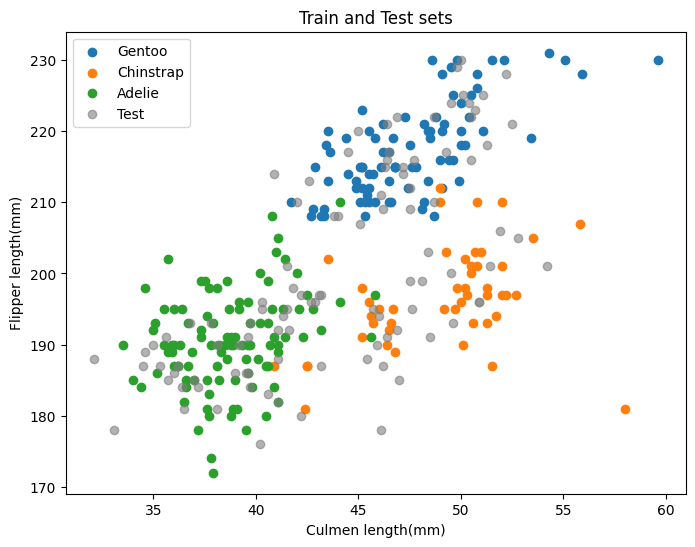

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

# обучающая выборка
for species in y_train.unique():
  mask = y_train == species

  plt.scatter(
    X_train.loc[mask, "culmen_length_mm"],
    X_train.loc[mask, "flipper_length_mm"],
    label=species
  )

# тестовая выборка
plt.scatter(
  X_test["culmen_length_mm"],
  X_test["flipper_length_mm"],
  color="gray",
  alpha=0.6,
  label="Test"
)

plt.xlabel("Culmen length(mm)")
plt.ylabel("Flipper length(mm)")
plt.title("Train and Test sets")
plt.legend()

plt.show()

## Задание 2. Метрики

На построенном графике рассеяния ты видишь 3 больших кластера в пространстве признаков длины клюва и длины ласт. Каждый кластер соответствует одному из видов пингвинов. Теперь для серых точек (тестовой выборки) нужно найти ближайшие точки из обучающей выборки, чтобы понять, к какому классу их отнести.

Для определения функции расстояния между точками в пространстве признаков существуют различные метрики. В этом задании ты реализуешь несколько основных метрик расстояния, которые используются в метрических алгоритмах.

1. **Реализуй метрику Минковского:**
   - Метрика Минковского — это обобщенная метрика расстояния, которая 
   включает в себя множество других метрик как частные случаи.
   - Формула метрики Минковского для двух точек 
   
   $p = (p_1, p_2, ..., p_n)$ и $q = (q_1, q_2, ..., q_n)$:
   $$d(p, q) = \left(\sum_{i=1}^{n} |p_i - q_i|^p\right)^{1/p}$$
   
   где $p$ — параметр метрики (не путай с точкой $p$).
   - Реализуй функцию `minkowski_distance(point1, point2, p)`, которая 
   принимает две точки (массивы или списки) и параметр $p$, и возвращает 
   расстояние Минковского между ними.


2. **Реализуй евклидову и манхэттенскую метрики:**
   - Евклидова метрика — это частный случай метрики Минковского при $p = 2$.
   Это стандартное расстояние между точками в евклидовом пространстве, 
   которое ты изучал в геометрии.
   - Манхэттенская метрика (также известная как метрика L1 или 
   «city block distance») — это частный случай метрики Минковского при 
   $p = 1$. Название происходит от того, что это расстояние, которое нужно 
   пройти по улицам прямоугольной сетки (как в Манхэттене), где можно 
   двигаться только горизонтально и вертикально.
   - Реализуй функции `euclidean_distance(point1, point2)` и 
   `manhattan_distance(point1, point2)`, используя реализованную ранее 
   метрику Минковского.


3. **Расчет расстояния:**
   - Для точки из тестовой выборки с минимальным `culmen_length_mm` 
   рассчитай манхэттенское расстояние от точки (45, 200).
   - Для точки из тестовой выборки с максимальным `flipper_length_mm` 
   рассчитай евклидово расстояние от точки (45, 200).
   - Визуализируй только эти точки и точку (45, 200). 

In [7]:
# Метрика Минковского
def minkowski_distance(point1, point2, p):
    return sum(abs(a - b) ** p for a, b in zip(point1, point2)) ** (1 / p)

In [8]:
# Евклидова метрика
def euclidean_distance(point1, point2):
    return minkowski_distance(point1, point2, 2)

In [9]:
# Манхэттенская метрика
def manhattan_distance(point1, point2):
    return minkowski_distance(point1, point2, 1)

In [10]:
point_min = X_test.loc[X_test["culmen_length_mm"].idxmin()]
point_max = X_test.loc[X_test["flipper_length_mm"].idxmax()]

print(point_min)
print()
print(point_max)

culmen_length_mm      32.1
flipper_length_mm    188.0
Name: 142, dtype: float64

culmen_length_mm      50.0
flipper_length_mm    230.0
Name: 221, dtype: float64


In [11]:
point1 = [
  point_min["culmen_length_mm"],
  point_min["flipper_length_mm"]
]

point2 = [
  point_max["culmen_length_mm"],
  point_max["flipper_length_mm"]
]

reference = [45, 200]

manhattan = manhattan_distance(point1, reference)
euclidean = euclidean_distance(point2, reference)

print(manhattan)
print(euclidean)

24.9
30.4138126514911


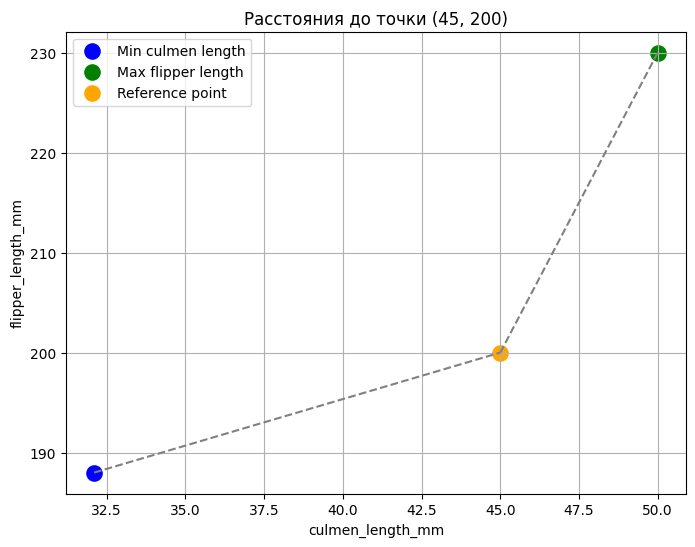

In [12]:
plt.figure(figsize=(8, 6))

plt.scatter(
  point1[0],
  point1[1],
  color="blue",
  s=120,
  label="Min culmen length"
)

plt.plot(
  [point1[0], reference[0]],
  [point1[1], reference[1]],
  "--",
  color="gray"
)

plt.scatter(
  point2[0],
  point2[1],
  color="green",
  s=120,
  label="Max flipper length"
)

plt.plot(
  [point2[0], reference[0]],
  [point2[1], reference[1]],
  "--",
  color="gray"
)

plt.scatter(
  reference[0],
  reference[1],
  color="orange",
  s=120,
  label="Reference point"
)

plt.xlabel("culmen_length_mm")
plt.ylabel("flipper_length_mm")
plt.title("Расстояния до точки (45, 200)")
plt.legend()

plt.grid(True)
plt.show()

## Задание 3. Ближайшие соседи

В этом задании ты реализуешь алгоритм 1-NN (k=1), где для каждой точки из 
тестовой выборки находится ближайший сосед из обучающей выборки, и класс 
этого соседа присваивается тестовой точке.

1. **Реализация поиска ближайшего соседа:**
   - Реализуй функцию `find_nearest_neighbor(test_point, train_data, 
   train_labels, distance_func)`, которая находит ближайшего соседа для 
   тестовой точки и возвращает метку его класса.

2. **Классификация тестовой выборки:**
   - Используй только признаки `culmen_length_mm` и `flipper_length_mm` для 
   классификации.
   - Для каждой точки из тестовой выборки найди ближайшего соседа из 
   обучающей выборки, используя евклидову метрику расстояния.
   - Определи класс для каждой тестовой точки на основе класса ее 
   ближайшего соседа.

3. **Оценка точности классификации:**
   - Посчитай точность классификации, сравнив предсказанные классы с 
   реальными метками тестовой выборки.
   - Выведи значение точности в процентах с округлением до 2 знаков после 
   запятой.

4. **Визуализация результатов:**
   - Построй график рассеяния с обучающей и тестовой выборками (используй 
   те же два признака, что и ранее: длина клюва и длина ласт).
   - Обучающая выборка: точки окрашены по реальным классам.
   - Тестовая выборка: точки окрашены по предсказанным классам.
   - Для каждой тестовой точки проведи линию к ее ближайшему соседу.
   - Добавь подписи осей, заголовок и легенду.

5. **Сравнение с sklearn:**
   - Используй `KNeighborsClassifier` из `sklearn.neighbors` с `n_neighbors=1` 
   для классификации тестовой выборки.
   - Сравни полученную точность с результатом своей реализации.

In [13]:
from collections import Counter

def find_nearest_neighbor(test_point, train_data, train_labels, distance_func):
  distances = []

  for i in range(len(train_data)):
      dist = distance_func(test_point, train_data.iloc[i].values)
      distances.append([dist, train_labels.iloc[i], i])
  
  distances.sort(key=lambda x: x[0])
  
  return distances[0]

In [14]:
target_cols = ["culmen_length_mm", "flipper_length_mm"]

predictions = []
nearest_indices = []

for i in range(len(X_test)):
    distance, label, index = find_nearest_neighbor(
        X_test[target_cols].iloc[i].values,
        X_train[target_cols],
        y_train,
        euclidean_distance
    )

    predictions.append(label)
    nearest_indices.append(index)

In [15]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, predictions)

print(f"Accuracy: {accuracy:.4f}")
print(f"Точность модели: {accuracy * 100:.2f}%")

Accuracy: 0.9505
Точность модели: 95.05%


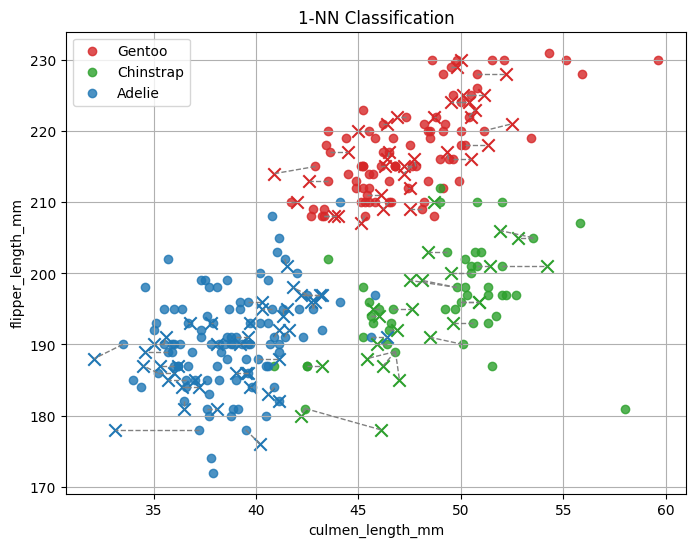

In [16]:
colors = {
    "Adelie": "tab:blue",
    "Chinstrap": "tab:green",
    "Gentoo": "tab:red"
}

plt.figure(figsize=(8, 6))

for species in y_train.unique():
  mask = y_train == species

  plt.scatter(
    X_train.loc[mask, "culmen_length_mm"],
    X_train.loc[mask, "flipper_length_mm"],
    color=colors[species],
    label=species,
    alpha=0.8
  )

for i in range(len(X_test)):
  plt.scatter(
    X_test.iloc[i]["culmen_length_mm"],
    X_test.iloc[i]["flipper_length_mm"],
    color=colors[predictions[i]],
    marker="x",
    s=80
  )

for i in range(len(y_test)):
  train_point = X_train.iloc[nearest_indices[i]]
  test_point = X_test.iloc[i]

  plt.plot(
    [train_point["culmen_length_mm"],
     test_point["culmen_length_mm"]],

    [train_point["flipper_length_mm"],
     test_point["flipper_length_mm"]],

    color="gray",
    linestyle="--",
    linewidth=1
  )

plt.xlabel("culmen_length_mm")
plt.ylabel("flipper_length_mm")

plt.title("1-NN Classification")

plt.legend()

plt.grid(True)

plt.show()

In [17]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=1)
knn.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",1
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [18]:
y_pred = knn.predict(X_test)
sklearn_accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {sklearn_accuracy:.4f}")
print(f"Точность модели: {sklearn_accuracy * 100:.2f}%")

Accuracy: 0.9505
Точность модели: 95.05%


In [19]:
print(f"Разница в точности: {abs(accuracy - sklearn_accuracy):.4f}")

Разница в точности: 0.0000


## Задание 4. Больше соседей

В предыдущем задании ты использовал алгоритм 1-NN (k=1), где для классификации 
брал только одного ближайшего соседа. Теперь ты изучишь, как изменение 
количества соседей влияет на качество классификации. Это важный шаг в 
понимании того, как параметр k влияет на переобучение и недообучение модели.

1. **Исследование влияния количества соседей:**
   - Используй `KNeighborsClassifier` из `sklearn.neighbors` для классификации.
   - Проверь количество соседей от 1 до 30 включительно (k от 1 до 30).
   - Для каждого значения k обучи классификатор на обучающей выборке и 
   вычисли точность на обучающей и тестовой выборках.
   - Сохрани результаты в два списка: один для точности на обучающей выборке, 
   другой для точности на тестовой выборке.

2. **Визуализация зависимости точности от количества соседей:**
   - Построй график, на котором по оси X отложено количество соседей (k), а 
   по оси Y — точность классификации.
   - На графике должны быть две линии:
     - Линия для точности на обучающей выборке (train accuracy).
     - Линия для точности на тестовой выборке (test accuracy).
   - Используй разные цвета и маркеры для каждой линии.
   - Добавь подписи осей, заголовок графика и легенду.
   - Добавь сетку для удобства чтения значений.

In [20]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

accuracy_list_train = []
accuracy_list_test = []

for k in range(1, 31):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)

    # обучающая выборка
    y_pred_train = knn.predict(X_train)
    acc_train = accuracy_score(y_train, y_pred_train)
    accuracy_list_train.append(acc_train)

    # тестовая выборка
    y_pred_test = knn.predict(X_test)
    acc_test = accuracy_score(y_test, y_pred_test)
    accuracy_list_test.append(acc_test)

In [21]:
print(accuracy_list_test)
print(accuracy_list_train)

[0.9504950495049505, 0.9405940594059405, 0.9702970297029703, 0.9702970297029703, 0.9702970297029703, 0.9603960396039604, 0.9603960396039604, 0.9603960396039604, 0.9603960396039604, 0.9603960396039604, 0.9603960396039604, 0.9603960396039604, 0.9603960396039604, 0.9504950495049505, 0.9504950495049505, 0.9504950495049505, 0.9504950495049505, 0.9504950495049505, 0.9603960396039604, 0.9405940594059405, 0.9405940594059405, 0.9306930693069307, 0.9306930693069307, 0.9306930693069307, 0.9306930693069307, 0.9306930693069307, 0.9306930693069307, 0.9306930693069307, 0.9306930693069307, 0.9306930693069307]
[1.0, 0.9613733905579399, 0.9613733905579399, 0.9613733905579399, 0.9613733905579399, 0.9527896995708155, 0.9527896995708155, 0.9484978540772532, 0.9399141630901288, 0.9356223175965666, 0.9356223175965666, 0.9356223175965666, 0.944206008583691, 0.9356223175965666, 0.9399141630901288, 0.9399141630901288, 0.944206008583691, 0.9399141630901288, 0.944206008583691, 0.944206008583691, 0.944206008583691

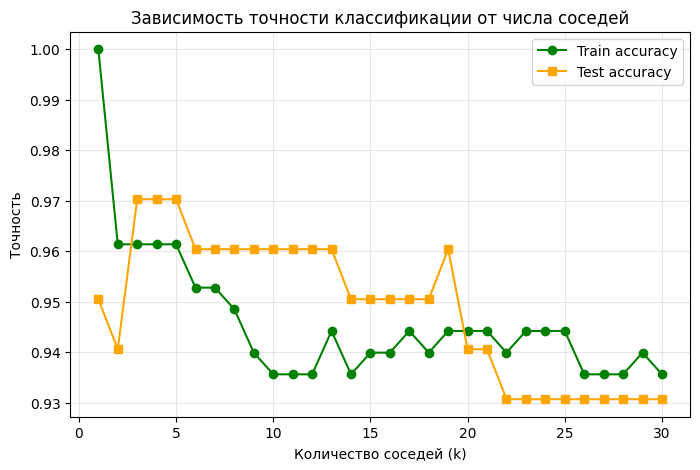

In [22]:
import matplotlib.pyplot as plt

k_s = list(range(1, 31))

plt.figure(figsize=(8, 5))

plt.plot(
    k_s,
    accuracy_list_train,
    color="green",
    marker="o",
    label="Train accuracy"
)

plt.plot(
    k_s,
    accuracy_list_test,
    color="orange",
    marker="s",
    label="Test accuracy"
)

plt.xlabel("Количество соседей (k)")
plt.ylabel("Точность")
plt.title("Зависимость точности классификации от числа соседей")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

## Задание 5. Стандартизация признаков

В предыдущих заданиях ты работал с признаками, которые имели схожие масштабы 
(длина клюва и длина ласт измеряются в миллиметрах). Однако в реальных задачах 
признаки часто имеют разные единицы измерения и масштабы. Например, масса тела 
пингвина измеряется в граммах (значения порядка тысяч), а длина клюва — в 
миллиметрах (значения порядка десятков).

Когда признаки имеют разные масштабы, метрики расстояния (например, евклидова 
метрика) будут в основном определяться признаком с большими значениями. Это 
может привести к тому, что важные закономерности в признаках с меньшими 
значениями будут проигнорированы, что негативно скажется на качестве 
классификации.

![Стандартизация](../misc/images/standardization.png)

**Стандартизация** — это процесс преобразования признаков таким образом, чтобы 
они имели нулевое среднее значение и единичную дисперсию. Это позволяет всем 
признакам вносить равный вклад в вычисление расстояний, независимо от их 
исходных масштабов.

1. **Работа с признаками разного масштаба:**
   - Используй признаки `body_mass_g` (масса тела) и `culmen_length_mm` 
   (длина клюва) для классификации.
   - Обучи модель k-NN на этих признаках с параметром k=3.
   - Вычисли точность классификации на тестовой выборке.
   - Визуализируй данные в пространстве этих признаков: построй график 
   рассеяния с обучающей и тестовой выборками, где точки окрашены по классам.

2. **Анализ проблемы масштабов:**
   - Выведи статистику по признакам (среднее, стандартное отклонение, минимум, 
   максимум) для обучающей выборки.
   - Объясни, почему признаки с разными масштабами могут создавать проблемы 
   для метрических алгоритмов.

3. **Применение стандартизации:**
   - Используй `StandardScaler` из `sklearn.preprocessing` для стандартизации 
   признаков.
   - Примени `fit_transform` к обучающей выборке и `transform` к тестовой 
   выборке (важно: стандартизация должна быть обучена только на обучающих 
   данных!).
   - Выведи среднее значение и дисперсию стандартизированных признаков для 
   обучающей выборки.
   - Убедись, что среднее значение близко к 0, а дисперсия близка к 1 для 
   каждого признака.

4. **Переобучение модели на стандартизированных данных:**
   - Обучи модель k-NN на стандартизированных признаках с параметром k=3.
   - Вычисли точность классификации на тестовой выборке.
   - Сравни точность до и после стандартизации.
   - Визуализируй стандартизированные данные: построй график рассеяния с 
   обучающей и тестовой выборками.

5. **Сравнение результатов:**
   - Сравни визуально графики до и после стандартизации: как изменилось 
   распределение точек в пространстве признаков?

In [23]:
cleaned_data.head(1)

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE


In [24]:
new_target_cols = ["culmen_length_mm", "body_mass_g"]

new_X = cleaned_data[new_target_cols]
new_y = y

In [25]:
from sklearn.model_selection import train_test_split

new_X_train, new_X_test, new_y_train, new_y_test = train_test_split(new_X, new_y, test_size=0.3, random_state=42)

print(new_X_train.shape, new_X_test.shape, new_y_train.shape, new_y_test.shape)

(233, 2) (101, 2) (233,) (101,)


In [26]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

new_knn = KNeighborsClassifier(n_neighbors=3)
new_knn.fit(new_X_train, new_y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",3
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [27]:
new_y_pred = new_knn.predict(new_X_test)
new_accuracy = accuracy_score(new_y_test, new_y_pred)

print(f"Accuracy: {new_accuracy:.4f}")
print(f"Точность новой модели: {new_accuracy * 100:.2f}%")

Accuracy: 0.7426
Точность новой модели: 74.26%


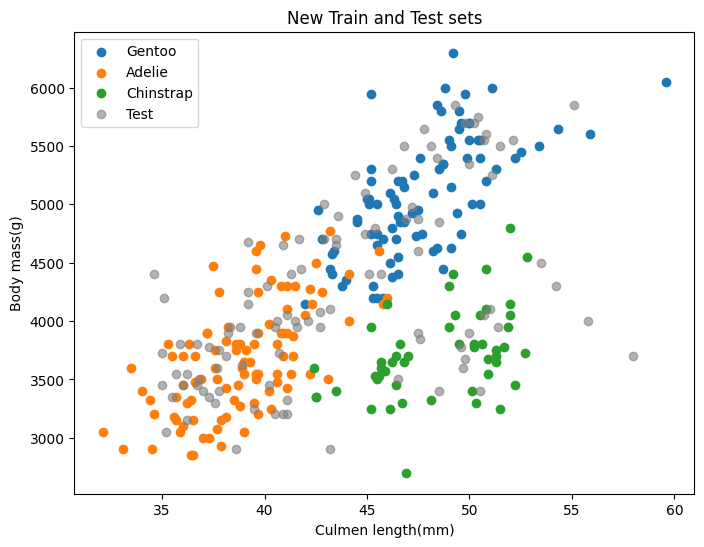

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

# обучающая выборка
for species in new_y_train.unique():
  mask = new_y_train == species

  plt.scatter(
    new_X_train.loc[mask, "culmen_length_mm"],
    new_X_train.loc[mask, "body_mass_g"],
    label=species
  )

# тестовая выборка
plt.scatter(
  new_X_test["culmen_length_mm"],
  new_X_test["body_mass_g"],
  color="gray",
  alpha=0.6,
  label="Test"
)

plt.xlabel("Culmen length(mm)")
plt.ylabel("Body mass(g)")
plt.title("New Train and Test sets")
plt.legend()

plt.show()

In [29]:
new_X_train.describe().loc[["mean", "std", "min", "max"]]

,culmen_length_mm,body_mass_g
mean,44.192704,4204.184549
std,5.337222,815.760157
min,32.100000,2700.000000
max,59.600000,6300.000000


Алгоритм k-NN вычисляет расстояния между объектами. Если один признак имеет значения порядка десятков (например, culmen_length_mm ≈ 40–60), а другой — тысяч (например, body_mass_g ≈ 3000–6000), то вклад второго признака в расстояние будет значительно больше. В результате признаки с большим масштабом начинают доминировать при вычислении расстояний, даже если они не являются наиболее важными для классификации. Поэтому перед применением k-NN обычно выполняют масштабирование признаков (например, с помощью StandardScaler).

In [30]:
from sklearn.preprocessing import StandardScaler

stscal = StandardScaler()

scaled_X_train = stscal.fit_transform(new_X_train)
scaled_X_test = stscal.transform(new_X_test)

print(f"Среднее: {scaled_X_train.mean()}")
print(f"Дисперсия: {scaled_X_train.std()}")

Среднее: -4.3074747393182037e-16
Дисперсия: 0.9999999999999999


In [31]:
new_knn.fit(scaled_X_train, new_y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",3
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [32]:
scaled_y_pred = new_knn.predict(scaled_X_test)
scaled_accuracy = accuracy_score(new_y_test, scaled_y_pred)

print(f"Accuracy: {scaled_accuracy:.4f}")
print(f"Точность новой модели на станд. данных: {scaled_accuracy * 100:.2f}%")
print(f"Разница до и после: {abs(new_accuracy - scaled_accuracy):.4f}")

Accuracy: 0.9505
Точность новой модели на станд. данных: 95.05%
Разница до и после: 0.2079


In [40]:
import pandas as pd

scaled_X_train = pd.DataFrame(
  scaled_X_train,
  columns=new_target_cols
)

scaled_X_test = pd.DataFrame(
  scaled_X_test,
  columns=new_target_cols
)

scaled_X_train.index = new_y_train.index
scaled_X_test.index = new_y_test.index

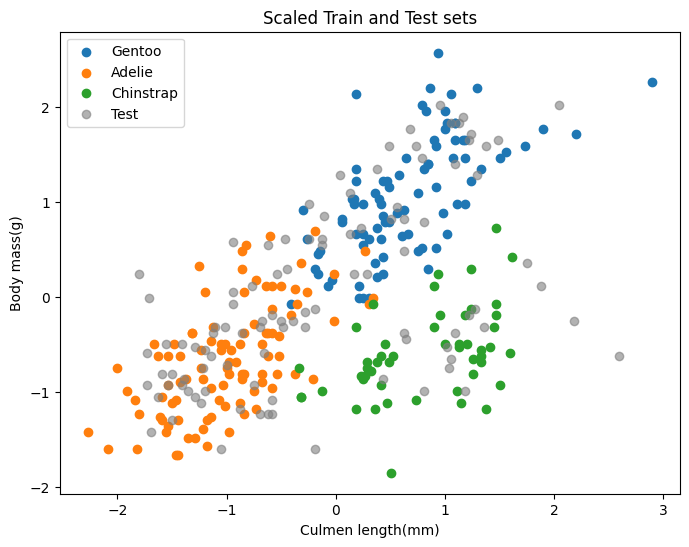

In [42]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

# обучающая выборка
for species in new_y_train.unique():
  mask = new_y_train == species

  plt.scatter(
    scaled_X_train.loc[mask, "culmen_length_mm"],
    scaled_X_train.loc[mask, "body_mass_g"],
    label=species
  )

# тестовая выборка
plt.scatter(
  scaled_X_test["culmen_length_mm"],
  scaled_X_test["body_mass_g"],
  color="gray",
  alpha=0.6,
  label="Test"
)

plt.xlabel("Culmen length(mm)")
plt.ylabel("Body mass(g)")
plt.title("Scaled Train and Test sets")
plt.legend()

plt.show()

После стандартизации все признаки были приведены к единому масштабу: их среднее значение стало близким к нулю, а стандартное отклонение — к единице. Благодаря этому ни один из признаков не доминирует при вычислении расстояний. Взаимное расположение объектов практически не изменилось, однако значения по осям стали сопоставимыми. Это особенно важно для алгоритма k-NN, поскольку он использует расстояния между объектами для классификации.

## Задание 6. Кросс-валидация

В предыдущих заданиях ты использовал фиксированное разделение данных на 
обучающую и тестовую выборки. Однако такой подход имеет ограничения: результат 
может сильно зависеть от того, как именно были разделены данные. Кроме того, 
при подборе гиперпараметров (таких как количество соседей k в алгоритме k-NN) 
использование тестовой выборки для оценки качества может привести к 
переобучению на тестовых данных.

**Гиперпараметр** — это параметр алгоритма, который задается до начала обучения 
и не изменяется в процессе обучения. В алгоритме k-NN гиперпараметром является 
количество соседей k. Правильный выбор гиперпараметра критически важен для 
качества модели: слишком маленькое k может привести к переобучению (модель 
запоминает шум в данных), а слишком большое — к недообучению (модель становится 
слишком простой и не учитывает локальные закономерности).

**K-fold кросс-валидация** — это метод оценки качества модели, при котором 
данные разбиваются на k частей (фолдов). Модель обучается k раз: каждый раз 
одна из частей используется как валидационная выборка, а остальные k-1 частей — 
как обучающая. В результате получается k оценок качества, которые можно 
усреднить для получения более надежной оценки.

![K-Fold](../misc/images/k_fold.png)


1. **Реализация k-fold кросс-валидации:**
   - Используй `cross_val_score` из `sklearn.model_selection` для проведения 
   кросс-валидации.
   - Проверь значения k от 1 до 30 включительно.
   - Используй 5-fold кросс-валидацию (cv=5).
   - Для каждого значения k вычисли среднюю точность и стандартное отклонение 
   по всем фолдам.

2. **Визуализация результатов кросс-валидации:**
   - Построй график, на котором по оси X отложено количество соседей (k), а по 
   оси Y — средняя точность классификации.
   - Добавь на график область, показывающую стандартное отклонение используй `fill_between`.
   - Добавь подписи осей, заголовок графика и легенду.
   - Добавь сетку для удобства чтения значений.

3. **Выбор оптимального гиперпараметра:**
   - Определи оптимальное значение k на основе результатов кросс-валидации 
   (значение с максимальной средней точностью).
   - Выведи оптимальное значение k и соответствующую ему среднюю точность.

In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

X = cleaned_data[["culmen_length_mm", "body_mass_g"]]
y = cleaned_data["species"]

mean_scores = []
std_scores = []

for k in range(1, 31):

    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsClassifier(n_neighbors=k))
    ])

    scores = cross_val_score(
        pipeline,
        X,
        y,
        cv=5,
        scoring="accuracy"
    )

    mean_scores.append(scores.mean())
    std_scores.append(scores.std())

print("Средняя точность для первых 5 k:")
print(mean_scores[:5])

print("\nСтандартное отклонение для первых 5 k:")
print(std_scores[:5])

# pipeline здесь используется для стандартизации исходных данных для каждого отдельного фолда

Средняя точность для первых 5 k:
[np.float64(0.9223428312980552), np.float64(0.9193577566711895), np.float64(0.9402532790592492), np.float64(0.9222976028946178), np.float64(0.9342379014020805)]

Стандартное отклонение для первых 5 k:
[np.float64(0.04844331507148341), np.float64(0.04862413079790627), np.float64(0.03263798923039442), np.float64(0.033110651231792576), np.float64(0.020085892720140098)]


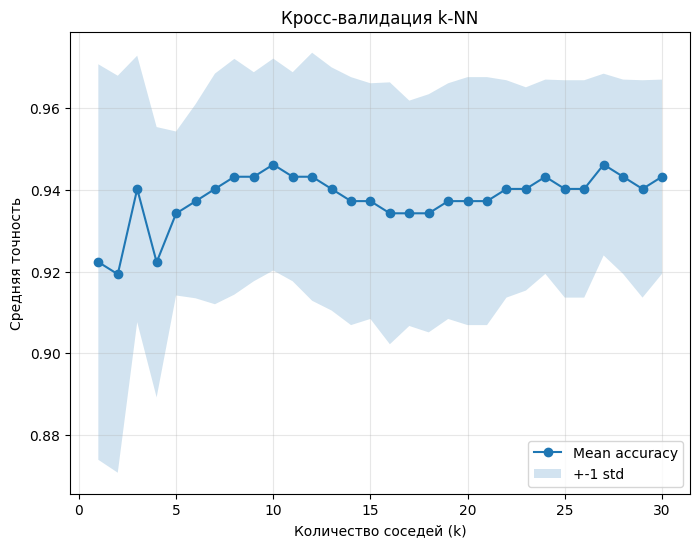

In [47]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.plot(
  k_s,
  mean_scores,
  marker="o",
  label="Mean accuracy"
)

plt.fill_between(
  k_s,
  [m - s for m, s in zip(mean_scores, std_scores)],
  [m + s for m, s in zip(mean_scores, std_scores)],
  alpha=0.2,
  label="+-1 std"
)

plt.xlabel("Количество соседей (k)")
plt.ylabel("Средняя точность")
plt.title("Кросс-валидация k-NN")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [48]:
print(f"Оптимальное значение k: {mean_scores.index(max(mean_scores))} - {max(mean_scores)}")

Оптимальное значение k: 9 - 0.9462234283129807


# Проблемы K-NN и проклятье размерности

Метрические алгоритмы, такие как k-NN, имеют множество преимуществ: они просты 
в понимании и реализации, не требуют явного обучения модели, хорошо работают 
с нелинейными зависимостями и легко адаптируются к новым данным. Однако у них 
есть и существенные ограничения.

Одной из главных проблем метрических алгоритмов является **проклятье 
размерности** (curse of dimensionality). С увеличением количества признаков 
объем пространства признаков растет экспоненциально, и данные становятся 
все более разреженными. В результате расстояния между точками становятся 
похожими друг на друга, что делает метрики расстояния менее информативными 
для классификации.

В этом разделе ты изучишь, как проклятье размерности влияет на качество 
классификации k-NN, и познакомишься с методом уменьшения размерности — 
анализом главных компонент (PCA), который позволяет уменьшить эту проблему.

![curse](../misc/images/curse.png)

## Задание 7. Генерация выборки

Для демонстрации проклятья размерности сгенерируй синтетический датасет с 
различным количеством признаков и проанализируй, как это влияет на качество 
классификации.

1. **Генерация данных:**
   - Используй `make_classification` из `sklearn.datasets` для генерации 
   датасета с 3 классами, 10000 образцами и различным количеством признаков: 
   от 10 до 100. Количество информативных признаков — 5.
   - Для каждого количества признаков раздели данные на обучающую (75%) и 
   тестовую (25%) выборки с `random_state=42`.

2. **Обучение и оценка:**
   - Для каждого количества признаков обучи модель k-NN с параметрами 
   `k=5` и `metric="euclidean"`.
   - Вычисли точность классификации на тестовой выборке и сохрани результаты 
   (количество признаков и соответствующая точность).

In [69]:
from sklearn.datasets import make_classification

datasets = []

for n_features in range(10, 101):
  X, y = make_classification(
    n_samples=10000,
    n_features=n_features,
    n_informative=5,
    n_redundant=0,
    n_classes=3,
    random_state=42
  )

  datasets.append([X, y])

In [70]:
from sklearn.model_selection import train_test_split

train_test_data = []

for i in range(len(datasets)):
  X_train, X_test, y_train, y_test = train_test_split(datasets[i][0], datasets[i][1], test_size=0.25, random_state=42)
  train_test_data.append([X_train, X_test, y_train, y_test])


In [71]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

acc_list = []

for i in range(len(train_test_data)):
  knn_k = KNeighborsClassifier(n_neighbors=5, metric="euclidean")
  knn_k.fit(train_test_data[i][0], train_test_data[i][2])

  y_pred = knn_k.predict(train_test_data[i][1])

  accuracy = accuracy_score(train_test_data[i][3], y_pred)

  acc_list.append([train_test_data[i][0].shape[1], accuracy])

In [72]:
print(acc_list[:20])

[[10, 0.8136], [11, 0.8028], [12, 0.7912], [13, 0.792], [14, 0.7644], [15, 0.7688], [16, 0.7568], [17, 0.756], [18, 0.744], [19, 0.7408], [20, 0.7392], [21, 0.73], [22, 0.728], [23, 0.6944], [24, 0.7196], [25, 0.7216], [26, 0.7124], [27, 0.6924], [28, 0.69], [29, 0.6988]]


## Задание 8. Проклятье размерности

Теперь визуализируй, как качество классификации изменяется с ростом 
количества признаков.

1. **Визуализация зависимости точности от размерности:**
   - Построй график, на котором по оси X отложено количество признаков, а 
   по оси Y — точность классификации на тестовой выборке.
   - Добавь подписи осей, заголовок графика и сетку.
   - Проанализируй график: как изменяется точность с увеличением количества 
   признаков?

2. **Анализ результатов:**
   - Определи размерность, при которой точность максимальна.
   - Объясни, почему точность сначала может расти (больше информации), а затем 
   падать (проклятье размерности).
   - Опиши, что такое проклятье размерности и почему оно возникает в 
   метрических алгоритмах.
   - Объясни, почему расстояния между точками становятся похожими при высокой 
   размерности.

In [73]:
acc_table = pd.DataFrame(
  acc_list,
  columns=["features_num", "accuracy"]
)

acc_table.head()

,features_num,accuracy
0,10,0.8136
1,11,0.8028
2,12,0.7912
3,13,0.7920
4,14,0.7644


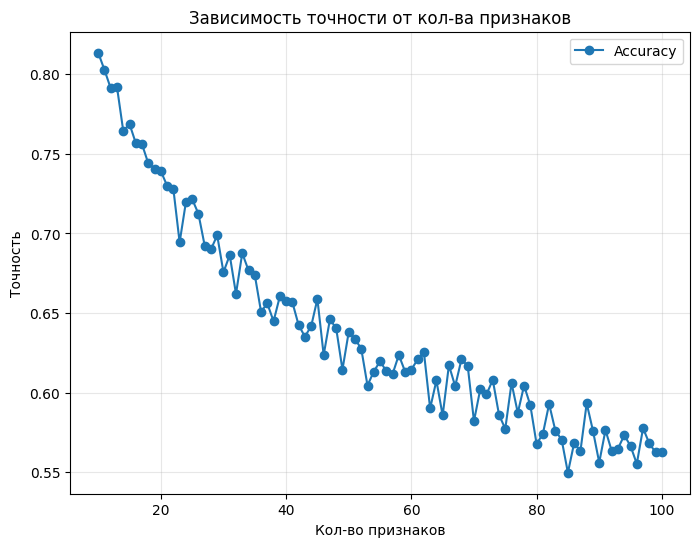

In [76]:
plt.figure(figsize=(8, 6))

plt.plot(
  acc_table["features_num"],
  acc_table["accuracy"],
  marker="o",
  label="Accuracy"
)

plt.xlabel("Кол-во признаков")
plt.ylabel("Точность")
plt.title("Зависимость точности от кол-ва признаков")
plt.legend()

plt.grid(alpha=0.3)

plt.show()

In [77]:
best_row = acc_table.loc[acc_table["accuracy"].idxmax()]

print(best_row)

features_num    10.0000
accuracy         0.8136
Name: 0, dtype: float64


Проклятие размерности — это явление, при котором с увеличением числа признаков данные становятся более разреженными, а эффективность алгоритмов, основанных на вычислении расстояний (например, k-NN), ухудшается. Для сохранения той же плотности данных требуется значительно больше объектов.

В нашем случае информативных признаков всего 5 и это число остается постоянным с увеличением признаков в целом. Точность в таком случае начнет падать почти сразу, так как увеличивается кол-во шумовых признаков, что наглядно представлено на графике.


Расстояния между признаками становятся похожими, поскольку каждая координата добавляет небольшой вклад, когда измерений очень много, и суммарные расстояния начинают концентрироваться около некоторого среднего значения.

## Задание 9. Уменьшение размерности

Для решения проблемы проклятья используется уменьшение размерности. В этом задании ты применишь анализ главных компонент (PCA) для снижения размерности признакового пространства.

1. **Применение PCA для уменьшения размерности:**
   - Используй те же данные, что и в задании 7.
   - Для каждого количества признаков примени PCA из `sklearn.decomposition` с параметрами `n_components=10` и `random_state=42`.
   - Важно: обучи PCA только на обучающей выборке (`fit`), затем примени к обеим выборкам (`transform`).
   - Обучи модель k-NN на уменьшенных признаках с параметрами `k=5` и `metric="euclidean"`.
   - Вычисли точность классификации на тестовой выборке для каждого количества признаков.
   - Сохрани результаты: количество признаков и соответствующую точность модели.

2. **Визуализация результатов:**
   - Построй график зависимости точности от количества признаков (как в задании 8): сравни результаты с PCA и без него.
   - Сделай вывод о том, как PCA влияет на точность классификации.


In [78]:
from sklearn.decomposition import PCA

pca = PCA(n_components=10, random_state=42)
train_test_pca = []

for i in range(len(train_test_data)):
  X_pca_train = pca.fit_transform(train_test_data[i][0])
  X_pca_test = pca.transform(train_test_data[i][1])

  train_test_pca.append([X_pca_train, X_pca_test])


In [79]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

result = []

for i in range(len(train_test_data)):
  knn_k = KNeighborsClassifier(n_neighbors=5, metric="euclidean")
  knn_k.fit(train_test_pca[i][0], train_test_data[i][2])

  y_pred = knn_k.predict(train_test_pca[i][1])

  accuracy = accuracy_score(train_test_data[i][3], y_pred)

  result.append([train_test_data[i][0].shape[1], accuracy])

In [80]:
result[:20]

[[10, 0.8136],
 [11, 0.7456],
 [12, 0.7628],
 [13, 0.7548],
 [14, 0.7512],
 [15, 0.7512],
 [16, 0.7372],
 [17, 0.7348],
 [18, 0.752],
 [19, 0.73],
 [20, 0.7316],
 [21, 0.7052],
 [22, 0.72],
 [23, 0.6948],
 [24, 0.7144],
 [25, 0.7216],
 [26, 0.7344],
 [27, 0.7176],
 [28, 0.716],
 [29, 0.7244]]

In [81]:
result = pd.DataFrame(
  result,
  columns=["features_num", "accuracy"]
)

result.head()

,features_num,accuracy
0,10,0.8136
1,11,0.7456
2,12,0.7628
3,13,0.7548
4,14,0.7512


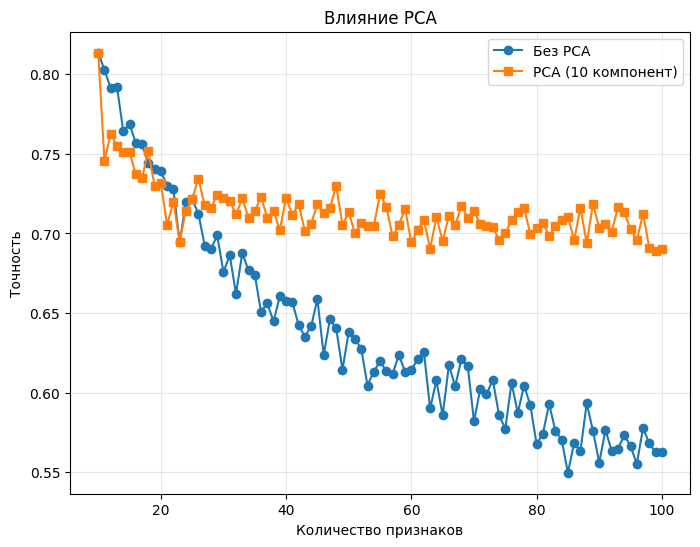

In [83]:
plt.figure(figsize=(8,6))

plt.plot(
    acc_table["features_num"],
    acc_table["accuracy"],
    marker="o",
    label="Без PCA"
)

plt.plot(
    result["features_num"],
    result["accuracy"],
    marker="s",
    label="PCA (10 компонент)"
)

plt.xlabel("Количество признаков")
plt.ylabel("Точность")
plt.title("Влияние PCA")

plt.grid(alpha=0.3)
plt.legend()

plt.show()

При небольшом количестве признаков точность классификации с PCA и без него практически совпадает. По мере увеличения размерности качество модели без PCA заметно ухудшается из-за проклятия размерности и влияния шумовых признаков. После применения PCA точность остается значительно более стабильной, поскольку данные проецируются в пространство из 10 главных компонент, сохраняющих основную информацию и уменьшающих влияние шума.

# Гибридный поиск фильмов

Алгоритмы поиска ближайших соседей активно используются в современных 
поисковых системах и рекомендательных сервисах. Когда ты ищешь фильм в 
онлайн-кинотеатре или товар в интернет-магазине, под капотом работают 
системы векторного поиска, которые находят похожие объекты по их 
семантическому сходству.

В реальных задачах поиска информации часто комбинируют классические 
алгоритмы (например, BM25, основанный на частоте терминов) и 
нейросетевые подходы (embeddings, полученные с помощью языковых моделей). 
Классические методы хорошо работают с точным совпадением ключевых слов, 
а нейросетевые модели лучше понимают семантику и синонимы. Гибридный 
поиск объединяет преимущества обоих подходов: он может находить 
релевантные результаты как по точному совпадению слов, так и по 
смысловому сходству.

В этом разделе ты реализуешь небольшой поисковый алгоритм для поиска 
фильмов, который будет использовать гибридный подход: комбинацию sparse-векторов (BM25) и dense-векторов (embeddings от языковых моделей). Это 
позволит тебе понять, как современные поисковые системы находят 
релевантную информацию и как можно комбинировать разные типы признаков 
для улучшения качества поиска.

![film](../misc/images/film_v1.png)


## Задание 10. Поиск по словам

В этом задании ты реализуешь поиск фильмов с использованием sparse 
векторов на основе алгоритма BM25. **Sparse-векторы** (разреженные векторы) 
— это векторы, в которых большинство элементов равны нулю. Они 
эффективно представляют текстовые документы, где каждая позиция 
соответствует определенному слову из словаря, а значение — частоте или 
важности этого слова в документе.

BM25 (Best Matching 25) — это классический алгоритм ранжирования в 
информационном поиске, который учитывает частоту терминов и обратную 
частоту документа. Он хорошо работает для точного поиска по ключевым 
словам и широко используется в поисковых системах.

1. **Загрузка и подготовка данных:**
   - Загрузи датасет с фильмами из файла `datasets/imdb_top_1000.csv` с 
   помощью библиотеки `pandas`.
   - Объедини название фильма (столбец `Series_Title`) и описание фильма 
   (столбец `Overview`) в единый текст. Создай новый столбец `text`, 
   который будет содержать объединенный текст в формате: «название 
   фильма. описание фильма».
   - Удали строки, где отсутствует значение в столбце `Overview` или 
   `Series_Title`.

2. **Создание коллекции в Qdrant:**
   - Установи и импортируй библиотеку [`qdrant-client`](https://github.com/qdrant/qdrant-client) для работы с векторной базой данных Qdrant. Qdrant — это векторная база данных, предназначенная для эффективного хранения и поиска по 
   многомерным векторам. Она позволяет хранить векторы вместе с 
   метаданными и выполнять быстрый поиск ближайших соседей, что 
   критически важно для задач семантического поиска и рекомендательных 
   систем.
   - Создай клиент Qdrant в режиме работы в памяти (in-memory mode).
   - Создай коллекцию с именем `movie_v1` для хранения векторов фильмов.
   - Настрой коллекцию для работы со sparse-векторами, используя модель 
   `Qdrant/bm25` для генерации векторов.

3. **Добавление данных в коллекцию:**
   - Для каждого фильма создай точку (point) в коллекции со следующими 
   параметрами:
     - `text` — объединенный текст (название и описание фильма);
     - `genre` — жанр фильма;
     - `rating` — рейтинг фильма;
     - `title` — название фильма.
   - Сгенерируй sparse-вектор для текста каждого фильма с помощью модели 
   `Qdrant/bm25`.
   - Добавь все точки в коллекцию `movie_v1`.

4. **Проверка коллекции:**
   - Выведи количество объектов в коллекции `movie_v1`.
   - Убедись, что количество объектов соответствует количеству фильмов в 
   датасете (после удаления строк с пропусками).

5. **Тестирование поиска:**
   - Выполни поиск по базе с запросом «superhero movie».
   - Выполни поиск по базе с запросом «thriller about a maniac».
   - Для каждого запроса выведи топ-5 найденных фильмов с их названиями, 
   жанрами и рейтингами.

In [2]:
import pandas as pd

movies = pd.read_csv("..\datasets\imdb_top_1000.csv")

movies = movies.dropna(subset=["Series_Title", "Overview"])

movies["text"] = movies["Series_Title"] + ". " + movies["Overview"]

movies.shape

<>:3: SyntaxWarning: invalid escape sequence '\d'
<>:3: SyntaxWarning: invalid escape sequence '\d'
C:\TEMP\ipykernel_15412\1452223390.py:3: SyntaxWarning: invalid escape sequence '\d'
  movies = pd.read_csv("..\datasets\imdb_top_1000.csv")


(1000, 17)

In [3]:
movies.head(2)

,Poster_Link,Series_Title,Released_Year,Certificate,Runtime,Genre,IMDB_Rating,Overview,Meta_score,Director,Star1,Star2,Star3,Star4,No_of_Votes,Gross,text
0,https://m.media-amazon.com/images/M/MV5BMDFkYT...,The Shawshank Redemption,1994,A,142 min,Drama,9.3,Two imprisoned men bond over a number of years...,80.0,Frank Darabont,Tim Robbins,Morgan Freeman,Bob Gunton,William Sadler,2343110,"28,341,469",The Shawshank Redemption. Two imprisoned men b...
1,https://m.media-amazon.com/images/M/MV5BM2MyNj...,The Godfather,1972,A,175 min,"Crime, Drama",9.2,An organized crime dynasty's aging patriarch t...,100.0,Francis Ford Coppola,Marlon Brando,Al Pacino,James Caan,Diane Keaton,1620367,"134,966,411",The Godfather. An organized crime dynasty's ag...


In [4]:
from qdrant_client import QdrantClient

client = QdrantClient(":memory:")

In [5]:
from qdrant_client import models

client.create_collection(
    collection_name="movie_v1",
    vectors_config={},
    sparse_vectors_config={
        "text": models.SparseVectorParams() # векторизоваться будет только текст фильма
    }
)

True

In [9]:
from qdrant_client import models

points = []

for idx, row in movies.iterrows():
    points.append(
        models.PointStruct(
            id=idx,
            vector={
                "text": models.Document(
                    text=row["text"],
                    model="Qdrant/minicoil-v1"
                )
            },
            payload={
                "title": row["Series_Title"],
                "genre": row["Genre"],
                "rating": row["IMDB_Rating"],
                "text": row["text"]
            }
        )
    )

## Задание 11. Семантический поиск

В предыдущем задании ты использовал sparse-векторы на основе BM25, 
которые хорошо работают для точного поиска по ключевым словам. Однако 
они не учитывают семантическое сходство: например, запрос «superhero 
movie» может не найти фильм, в описании которого используется слово 
«superhero» в другой форме или синоним.

**Dense-векторы** — это векторы, где большинство 
элементов имеют ненулевые значения. Они получаются с помощью нейросетевых 
языковых моделей и кодируют семантическое значение текста в многомерном пространстве. Такие векторы позволяют находить документы, которые семантически похожи на запрос, даже если они не содержат точных совпадений слов.

В этом задании ты реализуешь поиск фильмов с использованием dense-векторов, полученных с помощью модели `sentence-transformers/all-MiniLM-L6-v2`. 
Эта модель преобразует тексты в векторы размерности 384, которые 
кодируют семантическое значение текста.

1. **Подготовка данных:**
   - Используй тот же датасет, что и в задании 10 (с объединенным текстом 
   в столбце `text`).
   - Убедись, что данные подготовлены так же, как в предыдущем задании.

2. **Создание коллекции с dense-векторами:**
   - Создай новую коллекцию с именем `movie_v2` для хранения dense-векторов.
   - Настрой коллекцию для работы с dense-векторами размерности 384 
   (размерность векторов модели `all-MiniLM-L6-v2`).

3. **Генерация dense-векторов:**
   - Установи и импортируй библиотеку `sentence-transformers`.
   - Загрузи модель `sentence-transformers/all-MiniLM-L6-v2`.
   - Для каждого фильма сгенерируй dense-вектор, используя объединенный 
   текст (столбец `text`).
   - Добавь все точки в коллекцию `movie_v2` с теми же метаданными, что 
   и в задании 10: `text`, `genre`, `rating`, `title`.

4. **Проверка коллекции:**
   - Выведи количество объектов в коллекции `movie_v2`.
   - Убедись, что оно соответствует количеству фильмов в датасете.

5. **Тестирование поиска:**
   - Выполни поиск по базе с запросом «superhero movie» используя dense-векторы.
   - Выполни поиск по базе с запросом «thriller about a maniac».
   - Для каждого запроса выведи топ-5 найденных фильмов с их названиями, 
   жанрами и рейтингами.
   - Сравни результаты с результатами из задания 10: какие различия ты 
   заметил?

## Задание 12. Гибридный поиск

В предыдущих заданиях ты использовал два разных подхода к поиску: sparse-векторы и dense-векторы. Каждый подход имеет свои преимущества:

- **Sparse-векторы (BM25)** хорошо работают для точного совпадения ключевых слов и учитывают частоту терминов в документах.
- **Dense-векторы** лучше понимают семантику и могут находить релевантные результаты даже при отсутствии точных совпадений слов.

Гибридный поиск объединяет оба подхода: он комбинирует результаты поиска 
по sparse- и dense-векторам, взвешивая их с помощью метапараметров. Это 
позволяет получить более точные и релевантные результаты, используя 
преимущества обоих методов.

В этом задании ты реализуешь гибридный поиск, который будет использовать 
и sparse-, и dense-векторы одновременно.

1. **Создание коллекции с обоими типами векторов:**
   - Создай новую коллекцию с именем `movie_v3` для хранения как sparse-, 
   так и dense-векторов одновременно.
   - Настрой коллекцию для работы с обоими типами векторов:
     - Sparse-векторы (используй модель `Qdrant/bm25`).
     - Dense-векторы размерности 384 (используй модель 
     `sentence-transformers/all-MiniLM-L6-v2`).
   - Для каждого фильма создай точку в коллекции `movie_v3` с обоими 
   типами векторов и теми же метаданными: `text`, `genre`, `rating`, `title`.
   - Убедись, что количество объектов в коллекции соответствует 
   количеству фильмов в датасете.

2. **Реализация гибридного поиска:**
   - Создай функцию `hybrid_search`, которая принимает:
     - текстовый запрос,
     - вес для sparse поиска (параметр `sparse_weight`, по умолчанию 0.5),
     - вес для dense поиска (параметр `dense_weight`, по умолчанию 0.5),
     - количество результатов для возврата (параметр `limit`, по 
     умолчанию 5).
   - Функция должна:
     - Выполнить поиск по коллекции `movie_v3` с использованием sparse-векторов и получить результаты с их релевантными оценками (scores).
     - Выполнить поиск по той же коллекции `movie_v3` с использованием dense-векторов и получить результаты с их релевантными оценками.
     - Нормализовать оценки от обоих поисков (привести их к одному 
     масштабу, например, используя min-max нормализацию).
     - Объединить результаты, взвесив нормализованные оценки: 
     `final_score = sparse_weight * normalized_sparse_score + dense_weight * normalized_dense_score`.
     - Вернуть топ-N результатов, отсортированных по итоговой оценке.

3. **Тестирование гибридного поиска:**
   - Выполни гибридный поиск с запросом «superhero movie» с равными 
   весами (sparse_weight=0.5, dense_weight=0.5).
   - Выполни гибридный поиск с запросом «thriller about a maniac» с 
   равными весами.
   - Для каждого запроса выведи топ-5 найденных фильмов с их названиями, 
   жанрами, рейтингами и итоговыми оценками релевантности.

4. **Сравнение подходов:**
   - Сравни результаты гибридного поиска с результатами из заданий 10 и 11.
   - Проанализируй, какие фильмы появляются в результатах гибридного 
   поиска, но отсутствуют в результатах отдельных методов, и наоборот.
   - Сделай вывод о преимуществах гибридного подхода.

## Задание 13. Гибридный поиск с фильтрацией

В реальных поисковых системах часто требуется не только найти 
релевантные документы, но и отфильтровать их по дополнительным 
критериям. Например, при поиске фильмов пользователь может хотеть найти 
только фильмы определенного жанра или с рейтингом выше определенного 
значения.

В этом задании ты расширишь гибридный поиск, добавив возможность 
фильтрации по метаданным (жанр и рейтинг). Это позволит комбинировать 
семантический поиск с точными фильтрами, что является стандартной 
практикой в современных поисковых системах.

1. **Расширение функции гибридного поиска:**
   - Модифицируй функцию `hybrid_search` из задания 12, добавив 
   параметры фильтрации:
     - `genre_filter` — список жанров для фильтрации (например, 
     `["Drama", "Crime"]`). Если указан, должны возвращаться только 
     фильмы, жанр которых содержит хотя бы один из указанных жанров.
     - `min_rating` — минимальный рейтинг фильма (например, 8.0). Если 
     указан, должны возвращаться только фильмы с рейтингом не ниже 
     указанного значения.
   - Примени фильтры к результатам поиска после объединения sparse и 
   dense результатов, но до финальной сортировки.

2. **Тестирование поиска с фильтрацией по жанру:**
   - Выполни гибридный поиск с запросом «superhero movie» и фильтром по 
   жанру `["Action", "Adventure"]`.
   - Выполни гибридный поиск с запросом «thriller about a maniac» и 
   фильтром по жанру `["Thriller", "Horror"]`.
   - Для каждого запроса выведи топ-5 найденных фильмов с их названиями, 
   жанрами и рейтингами.

3. **Тестирование поиска с фильтрацией по рейтингу:**
   - Выполни гибридный поиск с запросом «superhero movie» и фильтром по 
   минимальному рейтингу 8.5.
   - Выполни гибридный поиск с запросом «thriller about a maniac» и 
   фильтром по минимальному рейтингу 8.0.
   - Для каждого запроса выведи топ-5 найденных фильмов.

4. **Тестирование комбинированной фильтрации:**
   - Выполни гибридный поиск с запросом «drama about family» с фильтром 
   по жанру `["Drama"]` и минимальному рейтингу 8.5.
   - Выведи топ-5 найденных фильмов с их названиями, жанрами и рейтингами.
   - Проанализируй, как комбинация фильтров влияет на результаты поиска.